# 09 - Custom Predictions Visual Demo
Run your own image(s) for both detection and classification and visualize outputs.


In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.append(str(PROJECT_ROOT / "src"))

DETECTION_ROOT = PROJECT_ROOT / "rooftop-solar-panels-object-detection"
CLASSIFICATION_ROOT = PROJECT_ROOT / "rooftop-solar-panels-image-classification" / "Faulty_solar_panel"

print("PROJECT_ROOT:", PROJECT_ROOT)

CLASSIFICATION_INDEX = PROJECT_ROOT / "data/processed/classification_index.csv"


PROJECT_ROOT: C:\Users\DigvijayYadav\Downloads\rooftop-solar-panel-dataset


## A) Custom Detection Prediction (visual boxes)
Set `CUSTOM_DET_IMAGE` to any image path you want to test.


Detection image (test split preferred): C:\Users\DigvijayYadav\Downloads\rooftop-solar-panel-dataset\data\processed\yolo_single_class\images\test\5c500ec4-3.jpg
Visualization saved: C:\Users\DigvijayYadav\Downloads\rooftop-solar-panel-dataset\artifacts\predictions\detection\5c500ec4-3_detected.jpg


,bbox_id,class_name,confidence,x1,y1,x2,y2
0,0,solar-panel,0.896109,5,32,253,129


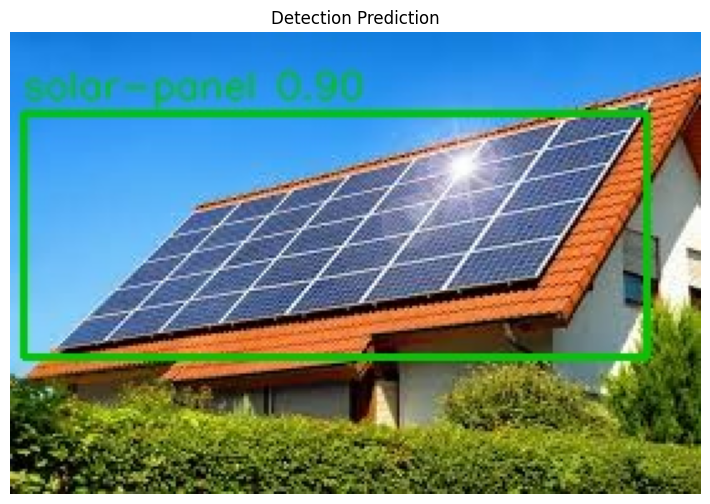

In [2]:
from detection_utils import predict_detection_on_image

# 1) Set your own image path here if needed
CUSTOM_DET_IMAGE = r"C:\Users\DigvijayYadav\Downloads\rooftop-solar-panel-dataset\data\processed\yolo_single_class\images\test\5c500ec4-3.jpg"  # Example: PROJECT_ROOT / "my_test_images" / "panel1.jpg"

# 2) Auto-resolve latest detection weights
det_candidates = sorted(
    (PROJECT_ROOT / "artifacts/models").glob("det_yolov8n_cpu*/weights/best.pt"),
    key=lambda p: p.stat().st_mtime,
    reverse=True,
)
det_weights = det_candidates[0] if det_candidates else None

# 3) Default to detection TEST split image if custom path is not set
image_suffixes = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
det_test_dir = PROJECT_ROOT / "data/processed/yolo_single_class/images/test"
det_test_images = [p for p in det_test_dir.rglob("*") if p.is_file() and p.suffix.lower() in image_suffixes] if det_test_dir.exists() else []
det_fallbacks = [p for p in (DETECTION_ROOT / "images").rglob("*") if p.is_file() and p.suffix.lower() in image_suffixes]
det_image = Path(CUSTOM_DET_IMAGE) if CUSTOM_DET_IMAGE else (det_test_images[0] if det_test_images else (det_fallbacks[0] if det_fallbacks else None))

if det_weights is None:
    raise FileNotFoundError("No detection best.pt found under artifacts/models/det_yolov8n_cpu*/weights/")
if det_image is None:
    raise FileNotFoundError("No detection image found. Run notebook 02 to create split or set CUSTOM_DET_IMAGE.")

det_df, det_viz_path = predict_detection_on_image(
    weights_path=det_weights,
    image_path=det_image,
    output_dir=PROJECT_ROOT / "artifacts/predictions/detection",
    conf=0.25,
)

print("Detection image (test split preferred):", det_image)
print("Visualization saved:", det_viz_path)
display(det_df)

plt.figure(figsize=(10, 6))
plt.imshow(Image.open(det_viz_path))
plt.axis("off")
plt.title("Detection Prediction")
plt.show()


## B) Custom Classification Prediction (single image)
Set `CUSTOM_CLS_IMAGE` to any panel image path and inspect top-k predictions.


Classification image (test split preferred): C:\Users\DigvijayYadav\Downloads\rooftop-solar-panel-dataset\rooftop-solar-panels-image-classification\Faulty_solar_panel\Snow-Covered\Snow (34).jpg


,class,probability
0,Snow-Covered,0.831422
1,Physical-Damage,0.156112
2,Bird-drop,0.006095
3,Electrical-damage,0.004100
4,Clean,0.001851


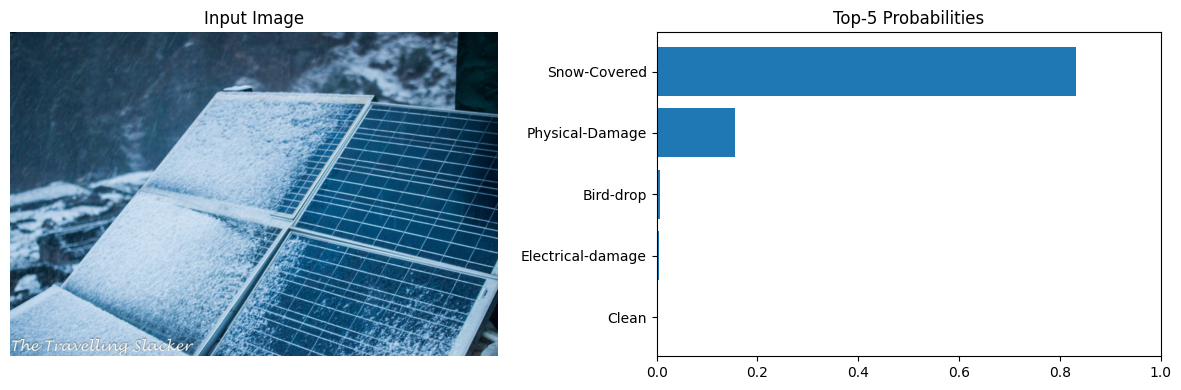

In [3]:
from classification_utils import predict_single_image

# 1) Set your own image path here if needed
CUSTOM_CLS_IMAGE = r"C:\Users\DigvijayYadav\Downloads\rooftop-solar-panel-dataset\rooftop-solar-panels-image-classification\Faulty_solar_panel\Snow-Covered\Snow (34).jpg"  # Example: PROJECT_ROOT / "my_test_images" / "panel_crop.jpg"

# 2) Auto-resolve latest classifier checkpoint
cls_candidates = sorted(
    (PROJECT_ROOT / "artifacts/models").glob("cls_*_cpu.pt"),
    key=lambda p: p.stat().st_mtime,
    reverse=True,
)
cls_ckpt = cls_candidates[0] if cls_candidates else None

# 3) Default to classification TEST split image from classification_index.csv
image_suffixes = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
cls_test_images = []
if CLASSIFICATION_INDEX.exists():
    split_df = pd.read_csv(CLASSIFICATION_INDEX)
    if {"file_path", "split"}.issubset(split_df.columns):
        cls_test_images = [
            Path(p) for p in split_df.loc[split_df["split"] == "test", "file_path"].tolist()
            if Path(p).exists() and Path(p).suffix.lower() in image_suffixes
        ]

cls_fallbacks = [p for p in CLASSIFICATION_ROOT.rglob("*") if p.is_file() and p.suffix.lower() in image_suffixes]
cls_image = Path(CUSTOM_CLS_IMAGE) if CUSTOM_CLS_IMAGE else (cls_test_images[0] if cls_test_images else (cls_fallbacks[0] if cls_fallbacks else None))

if cls_ckpt is None:
    raise FileNotFoundError("No classification checkpoint found under artifacts/models/cls_*_cpu.pt")
if cls_image is None:
    raise FileNotFoundError("No classification image found. Run notebook 05 to create split or set CUSTOM_CLS_IMAGE.")

topk = predict_single_image(image_path=cls_image, checkpoint_path=cls_ckpt, top_k=5)
pred_df = pd.DataFrame(topk)

print("Classification image (test split preferred):", cls_image)
display(pred_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(Image.open(cls_image))
axes[0].axis("off")
axes[0].set_title("Input Image")

axes[1].barh(pred_df["class"], pred_df["probability"])
axes[1].invert_yaxis()
axes[1].set_xlim(0, 1)
axes[1].set_title("Top-5 Probabilities")
plt.tight_layout()
plt.show()


## C) Optional Batch Classification for a Folder
Run top-1 predictions on all images in a custom folder.


In [5]:
from classification_utils import predict_directory

# If not set, run batch on classification TEST split folder inferred from classification_index.csv
CUSTOM_BATCH_DIR = None  # Example: PROJECT_ROOT / "my_test_images"

batch_dir = Path(CUSTOM_BATCH_DIR) if CUSTOM_BATCH_DIR else None
if batch_dir is None and CLASSIFICATION_INDEX.exists():
    split_df = pd.read_csv(CLASSIFICATION_INDEX)
    test_paths = split_df.loc[split_df["split"] == "test", "file_path"].tolist() if {"file_path", "split"}.issubset(split_df.columns) else []
    if test_paths:
        batch_dir = Path(test_paths[0]).parent

if batch_dir and batch_dir.exists():
    batch_df = predict_directory(batch_dir, cls_ckpt, top_k=3)
    out_csv = PROJECT_ROOT / "artifacts/predictions/classification_batch_predictions.csv"
    out_csv.parent.mkdir(parents=True, exist_ok=True)
    batch_df.to_csv(out_csv, index=False)
    print("Batch directory:", batch_dir)
    print("Saved:", out_csv)
    display(batch_df.head(20))
else:
    print("No batch directory resolved. Set CUSTOM_BATCH_DIR manually.")


Set CUSTOM_BATCH_DIR to run batch predictions.
